# Import Library (Menyiapkan Library)
## Mengimport library python yang akan di pakai seperti:
### - Pandas : untuk membaca data menjadi data tabular, memanipulasi data, pembersihan data dll
### - Numpy : untuk memperoses data numeric dan manipulasi array dengan efisien
### - Matplotlib & Seaborn : untuk memvisualisasikan data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
import json
from pathlib import Path

## Menyimpan dan mengubah bentuk data berbentuk CSV ke DataFrame ke variabel df serta mencari informasi terkait dataset

In [2]:
path = Path("../data/raw/jakarta_properties_raw.csv")
if path.exists():
    df = pd.read_csv(path)
else:
    print("data gaada")

In [3]:
df.sample()

,title,price_idr,city,district,bedrooms,bathrooms,garage,land_size_m2,building_size_m2,scraped_at
7425,Rumah Rawamangun - Termurah di Belakang Termin...,410000000.0,Jakarta Timur,Rawamangun,3.0,1.0,NaN,50.0,85.0,2026-04-28T09:07:47.334504+00:00


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 49953 entries, 0 to 49952
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   title             49953 non-null  str    
 1   price_idr         49953 non-null  float64
 2   city              49953 non-null  str    
 3   district          49953 non-null  str    
 4   bedrooms          48757 non-null  float64
 5   bathrooms         48787 non-null  float64
 6   garage            38587 non-null  float64
 7   land_size_m2      49930 non-null  float64
 8   building_size_m2  49874 non-null  float64
 9   scraped_at        49953 non-null  str    
dtypes: float64(6), str(4)
memory usage: 3.8 MB


In [5]:
df.describe()

,price_idr,bedrooms,bathrooms,garage,land_size_m2,building_size_m2
count,4.995300e+04,48757.000000,48787.000000,38587.000000,49930.000000,49874.000000
mean,1.130787e+10,5.052259,4.078402,2.869697,300.438594,335.734050
std,2.161632e+10,7.965665,3.915385,2.475343,436.796303,935.441777
min,7.950000e+06,1.000000,1.000000,1.000000,1.000000,1.000000
25%,2.550000e+09,3.000000,3.000000,1.000000,108.000000,148.000000
50%,4.700000e+09,4.000000,4.000000,2.000000,183.000000,240.000000
75%,1.000000e+10,6.000000,5.000000,4.000000,350.000000,400.000000
max,9.000000e+11,1314.000000,292.000000,70.000000,21754.000000,116799.000000


# Data Cleaning & Ubah type data
## Mengisi nilai di kolom garasi yang nan atau kosong jadi 0 & Mengubah Dtype kolom "price_idr" menjadi numeric lalu memfilter harga harus di atas 0

In [6]:
# Mengisi nilai nan atau null dengan 0
df['garage'] = df['garage'].fillna(0)

# Mengubah type data kolom "price_idr" menjadi numeric
df['price_idr'] = pd.to_numeric(df['price_idr'], errors='coerce')

# Memfilter agar setiap baris wajib memiliki harga, kasur, dan kamar mandi
df = df[(df['price_idr'] > 0) & (df['bedrooms'] > 0) & (df['bathrooms'] > 0)]

df = df[(df['building_size_m2'] >= 30) & (df['land_size_m2'] >= 30 )]

map_col = ['bedrooms','bathrooms','garage']

for col in map_col:
    df = df[(df[col] != df['land_size_m2']) & (df[col] != df['building_size_m2'])]

In [7]:
# Menghapus baris yang ada missing value di salah satu kolom 
df = df.dropna(axis=0) # (axis=0 untuk target baris, axis=1 untuk target kolom)

In [8]:
df.describe()

,price_idr,bedrooms,bathrooms,garage,land_size_m2,building_size_m2
count,4.810600e+04,48106.000000,48106.000000,48106.000000,48106.000000,48106.000000
mean,1.113516e+10,5.043550,4.085332,2.271650,297.890346,336.314306
std,2.085302e+10,7.198733,3.597660,2.467121,422.703908,948.128371
min,5.000000e+07,1.000000,1.000000,0.000000,30.000000,30.000000
25%,2.600000e+09,4.000000,3.000000,1.000000,108.000000,150.000000
50%,4.700000e+09,4.000000,4.000000,2.000000,182.000000,240.000000
75%,1.000000e+10,6.000000,5.000000,3.000000,350.000000,400.000000
max,6.000000e+11,1314.000000,292.000000,70.000000,21754.000000,116799.000000


In [9]:
df.duplicated().sum()

np.int64(0)

## Mencari tau sebaran data di kolom "price_idr" & Mencari Outlier

In [10]:
sns.set()

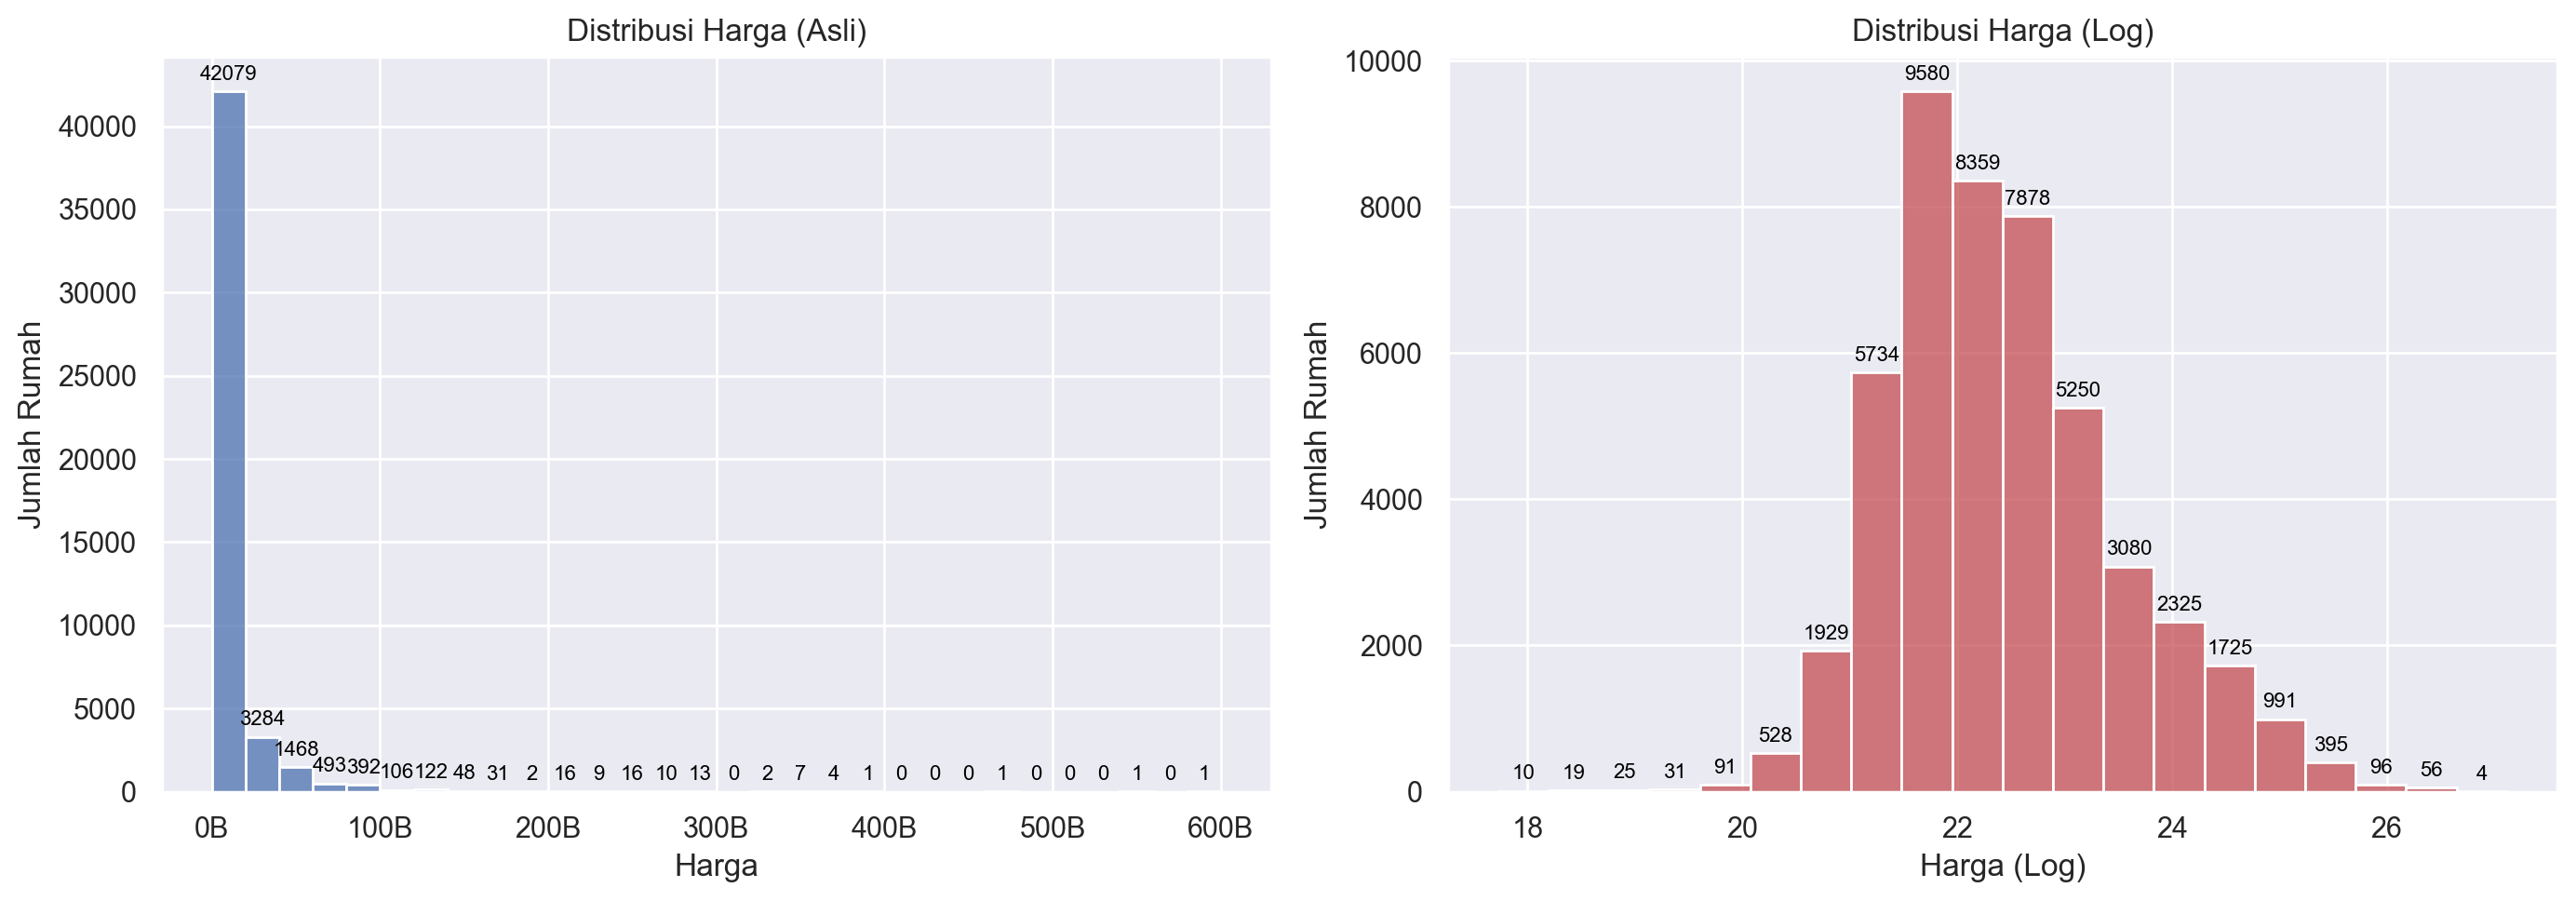

In [11]:
# Membuat figure dengan 1 baris 2 kolom dengan lebar 12 dan tinggi 5
fig , axes = plt.subplots(1,2,figsize=(14,5),dpi=200)

# Membuat axes pertama untuk menampilkan distribusi dengan nilai asli
sns.histplot(df['price_idr'],bins=30,color='b',ax=axes[0])
axes[0].bar_label(axes[0].containers[0],fontsize=8,color='black',padding=3)
axes[0].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1e9:.0f}B'))
axes[0].set_title('Distribusi Harga (Asli)')
axes[0].set_xlabel('Harga')
axes[0].set_ylabel('Jumlah Rumah')

# Membuat axes kedua untuk menampilkan distribusi dengan nilai log
sns.histplot(np.log1p(df['price_idr']),bins=20,color='r',ax=axes[1])
axes[1].bar_label(axes[1].containers[0],fontsize=8,color='black',padding=3)
axes[1].set_title('Distribusi Harga (Log)')
axes[1].set_xlabel('Harga (Log)')
axes[1].set_ylabel('Jumlah Rumah')

# Memberi jarak terhadap axes
fig.tight_layout()
plt.show()

### Mencari outliers menggunakan IQR (interquartile range) karena data harga asli right-skew atau tidak terdistribusi dengan normal untuk keperluan EDA

In [12]:
Q1 = df['price_idr'].quantile(0.25)
Q3 = df['price_idr'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['price_idr'] < lower) | (df['price_idr'] > upper)]
outliers_high = df[df['price_idr'] > upper]
outliers_low = df[df['price_idr'] < lower]
print(f'Batas Bawah: {lower}')
print(f'Batas Atas: {upper}')
print(f'Jumlah Total Outlier: {len(outliers)}')
print(f'Jumlah Outlier Di Bawah Batas Bawah: {len(outliers_low)}') 
print(f'Jumlah Outlier Di Atas Batas Atas: {len(outliers_high)}') 

Batas Bawah: -8500000000.0
Batas Atas: 21100000000.0
Jumlah Total Outlier: 5822
Jumlah Outlier Di Bawah Batas Bawah: 0
Jumlah Outlier Di Atas Batas Atas: 5822


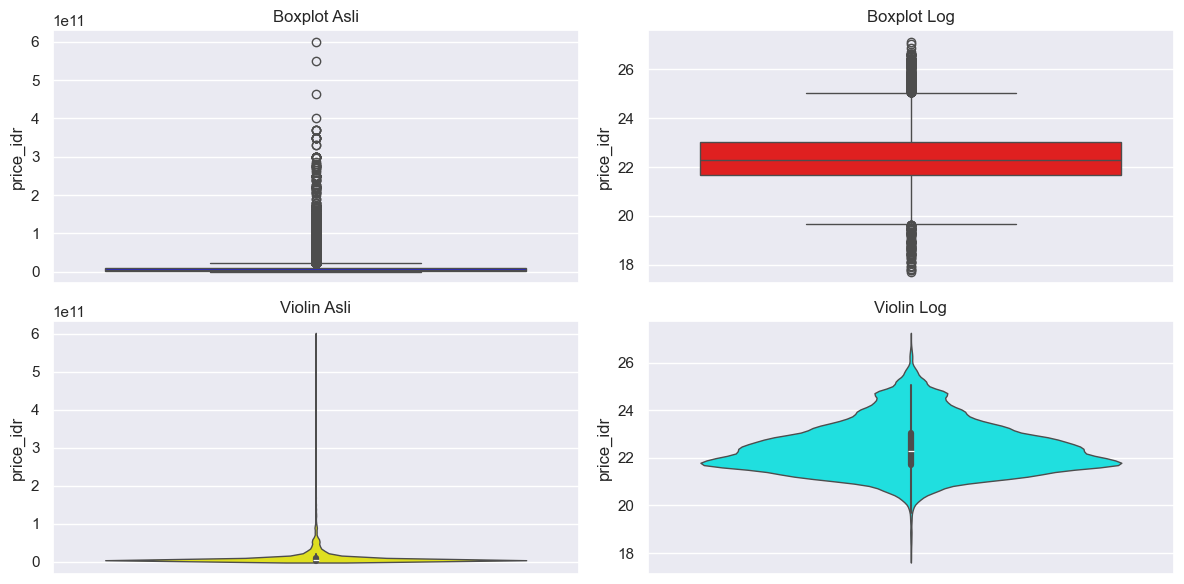

In [13]:

fig , ax = plt.subplots(2,2,figsize=(12,6))

sns.boxplot(y=df['price_idr'],ax=ax[0,0],color='blue')
ax[0,0].set_title('Boxplot Asli')

sns.boxplot(y=np.log1p(df['price_idr']),ax=ax[0,1],color='red')
ax[0,1].set_title('Boxplot Log')

sns.violinplot(y=df['price_idr'],ax=ax[1,0],bw_adjust=1, cut=1, linewidth=1,color='yellow')
ax[1,0].set_title('Violin Asli')

sns.violinplot(y=np.log1p(df['price_idr']),ax=ax[1,1],cut=1, linewidth=1,color='cyan')
ax[1,1].set_title('Violin Log')

plt.tight_layout()
plt.show()

## Insight Visualisasi Boxplot & Violin:
### Nilai Asli : Menunjukan kepadatan harga di antara 0-50M
### Nilai Log : Menunjukan sebaran harga terdistribusi dengan normal dan tidak menumpuk

## Mencari informasi data yang outliers

In [14]:
outliers.describe()

,price_idr,bedrooms,bathrooms,garage,land_size_m2,building_size_m2
count,5.822000e+03,5822.000000,5822.000000,5822.000000,5822.000000,5822.000000
mean,5.150807e+10,6.978873,5.862590,4.900034,886.613535,870.529371
std,3.995269e+10,6.499724,6.275747,4.411761,878.320794,2607.395356
min,2.120000e+10,1.000000,1.000000,0.000000,75.000000,30.000000
25%,2.800000e+10,5.000000,4.000000,2.000000,550.000000,482.000000
50%,3.900000e+10,6.000000,5.000000,4.000000,720.000000,650.000000
75%,5.800000e+10,7.000000,6.000000,7.000000,984.000000,1000.000000
max,6.000000e+11,121.000000,292.000000,70.000000,21754.000000,116799.000000


In [15]:
na = df[(df['price_idr'] > 50_000_000_000) & ((df['land_size_m2'] < 100) | (df['building_size_m2'] < 100))]
na

,title,price_idr,city,district,bedrooms,bathrooms,garage,land_size_m2,building_size_m2,scraped_at
46519,Tanah Komersil Siapbangun 8 Lantai Jl Wahid Ha...,1.260000e+11,Jakarta Pusat,Wahid Hasyim,1.0,1.0,2.0,1012.0,30.0,2026-05-21T20:46:31.311911+00:00
49241,Rumah Klasik Di Menteng Jakpus,6.900000e+10,Jakarta Pusat,Menteng,3.0,2.0,2.0,639.0,80.0,2026-05-22T15:18:43.528734+00:00


## Membatasi nilai baris yang memiliki rentang sangat jauh

In [16]:
lower = df['price_idr'].quantile(0.1)
upper = df['price_idr'].quantile(0.99)

df = df[
    (df['price_idr'] >= lower) &
    (df['price_idr'] <= upper)
]

In [17]:
df.describe()

,price_idr,bedrooms,bathrooms,garage,land_size_m2,building_size_m2
count,4.295700e+04,42957.000000,42957.000000,42957.000000,42957.000000,42957.000000
mean,1.065252e+10,5.228438,4.245478,2.331424,304.893475,343.749983
std,1.429514e+10,7.514358,3.591145,2.345002,329.954401,656.517943
min,1.650000e+09,1.000000,1.000000,0.000000,30.000000,30.000000
25%,3.000000e+09,4.000000,3.000000,1.000000,120.000000,168.000000
50%,5.400000e+09,5.000000,4.000000,2.000000,200.000000,250.000000
75%,1.100000e+10,6.000000,5.000000,3.000000,368.000000,403.000000
max,9.500000e+10,1314.000000,292.000000,47.000000,17500.000000,114030.000000


In [18]:
df['title'] = df['title'].str.lower()
df['cluster'] = df['title'].str.contains('cluster', na=False).astype(int)
df['pool'] = df['title'].str.contains(r'kolam renang|pool', na=False).astype(int)
df['mrt'] = df['title'].str.contains(r'mrt', na=False).astype(int)
df['tol'] = df['title'].str.contains(r'tol', na=False).astype(int)
df['mall'] = df['title'].str.contains(r'mall', na=False).astype(int)
df['kos'] = df['title'].str.contains(r'kos|kost|kostan|kosan', na=False).astype(int)
df['rumah_sakit'] = (df['title'].str.contains(r'rumah sakit', na=False) &~ df['title'].str.contains(r'dekat|near|sekitar|selangkah', na=False)).astype(int)
df = df[(df['kos'] == 0) & (df['rumah_sakit'] == 0)]

In [19]:
df = df[(df['rumah_sakit'] == 0) & (df['kos'] == 0)]
df = df.drop(columns=['rumah_sakit','kos'])
df.info()

<class 'pandas.DataFrame'>
Index: 41380 entries, 0 to 49951
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   title             41380 non-null  str    
 1   price_idr         41380 non-null  float64
 2   city              41380 non-null  str    
 3   district          41380 non-null  str    
 4   bedrooms          41380 non-null  float64
 5   bathrooms         41380 non-null  float64
 6   garage            41380 non-null  float64
 7   land_size_m2      41380 non-null  float64
 8   building_size_m2  41380 non-null  float64
 9   scraped_at        41380 non-null  str    
 10  cluster           41380 non-null  int64  
 11  pool              41380 non-null  int64  
 12  mrt               41380 non-null  int64  
 13  tol               41380 non-null  int64  
 14  mall              41380 non-null  int64  
dtypes: float64(6), int64(5), str(4)
memory usage: 5.1 MB


## Melihat Korelasi antar kolom
### Deskripsi:
### 0,00 – 0,25: Korelasi sangat lemah
### 0,25 – 0,50: Korelasi cukup/sedang
### 0,50 – 0,75: Korelasi kuat
### 0,75 – 0,99: Korelasi sangat kuat
### 1,00: Korelasi sempurna
### Note : Korelasi hanya menilai hubungungan antar 2 kolom bukan seluruh kolom, jadi jika korelasi lemah bukan berarti fitur tidak berguna

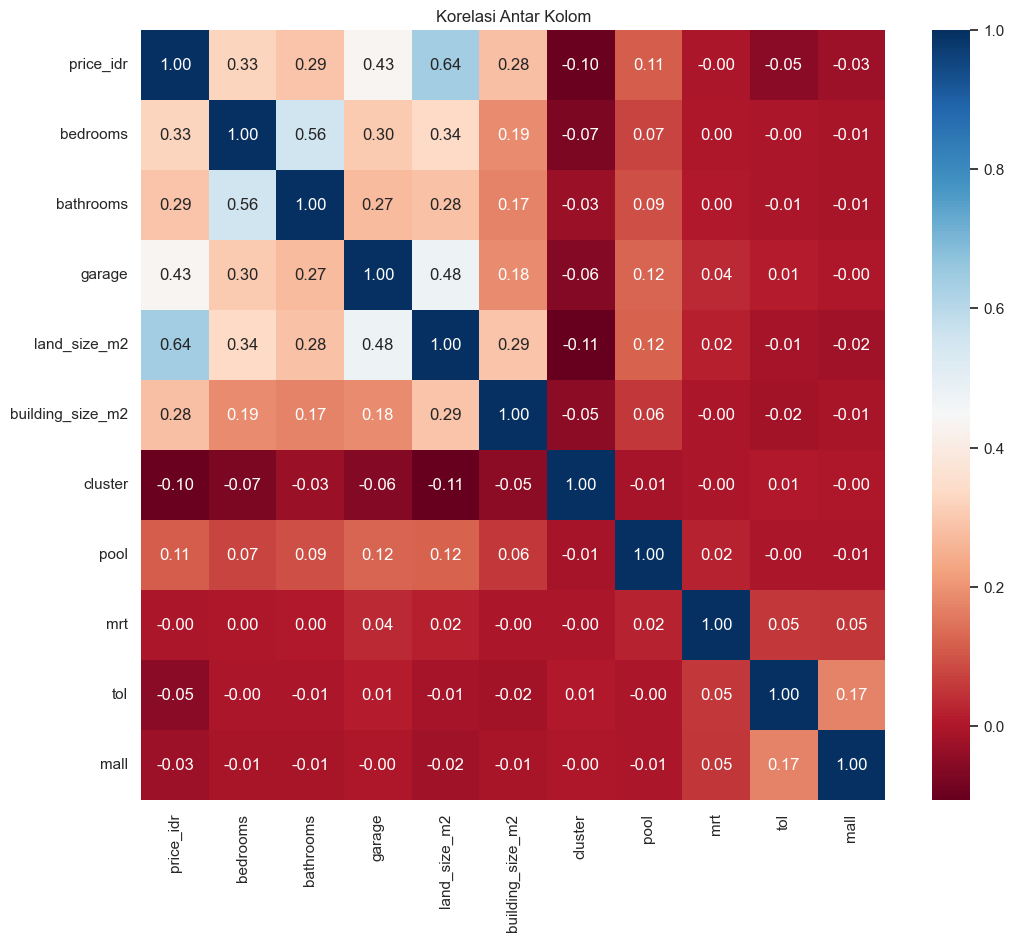

In [20]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='RdBu', fmt='.2f')
plt.title('Korelasi Antar Kolom')
plt.show()

In [21]:
df.describe()

,price_idr,bedrooms,bathrooms,garage,land_size_m2,building_size_m2,cluster,pool,mrt,tol,mall
count,4.138000e+04,41380.000000,41380.000000,41380.000000,41380.000000,41380.000000,41380.000000,41380.000000,41380.000000,41380.000000,41380.000000
mean,1.073424e+10,4.854157,3.995747,2.331537,305.695916,341.495408,0.061866,0.027356,0.010029,0.024553,0.013316
std,1.445922e+10,2.175468,2.287432,2.292178,332.369717,664.294829,0.240914,0.163121,0.099643,0.154760,0.114624
min,1.650000e+09,1.000000,1.000000,0.000000,30.000000,30.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000e+09,4.000000,3.000000,1.000000,120.000000,168.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5.300000e+09,5.000000,4.000000,2.000000,200.000000,250.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.100000e+10,6.000000,5.000000,3.000000,370.000000,400.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,9.500000e+10,110.000000,292.000000,47.000000,17500.000000,114030.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## Melihat distribusi atau sebaran kolom lain menggunakan histoplot

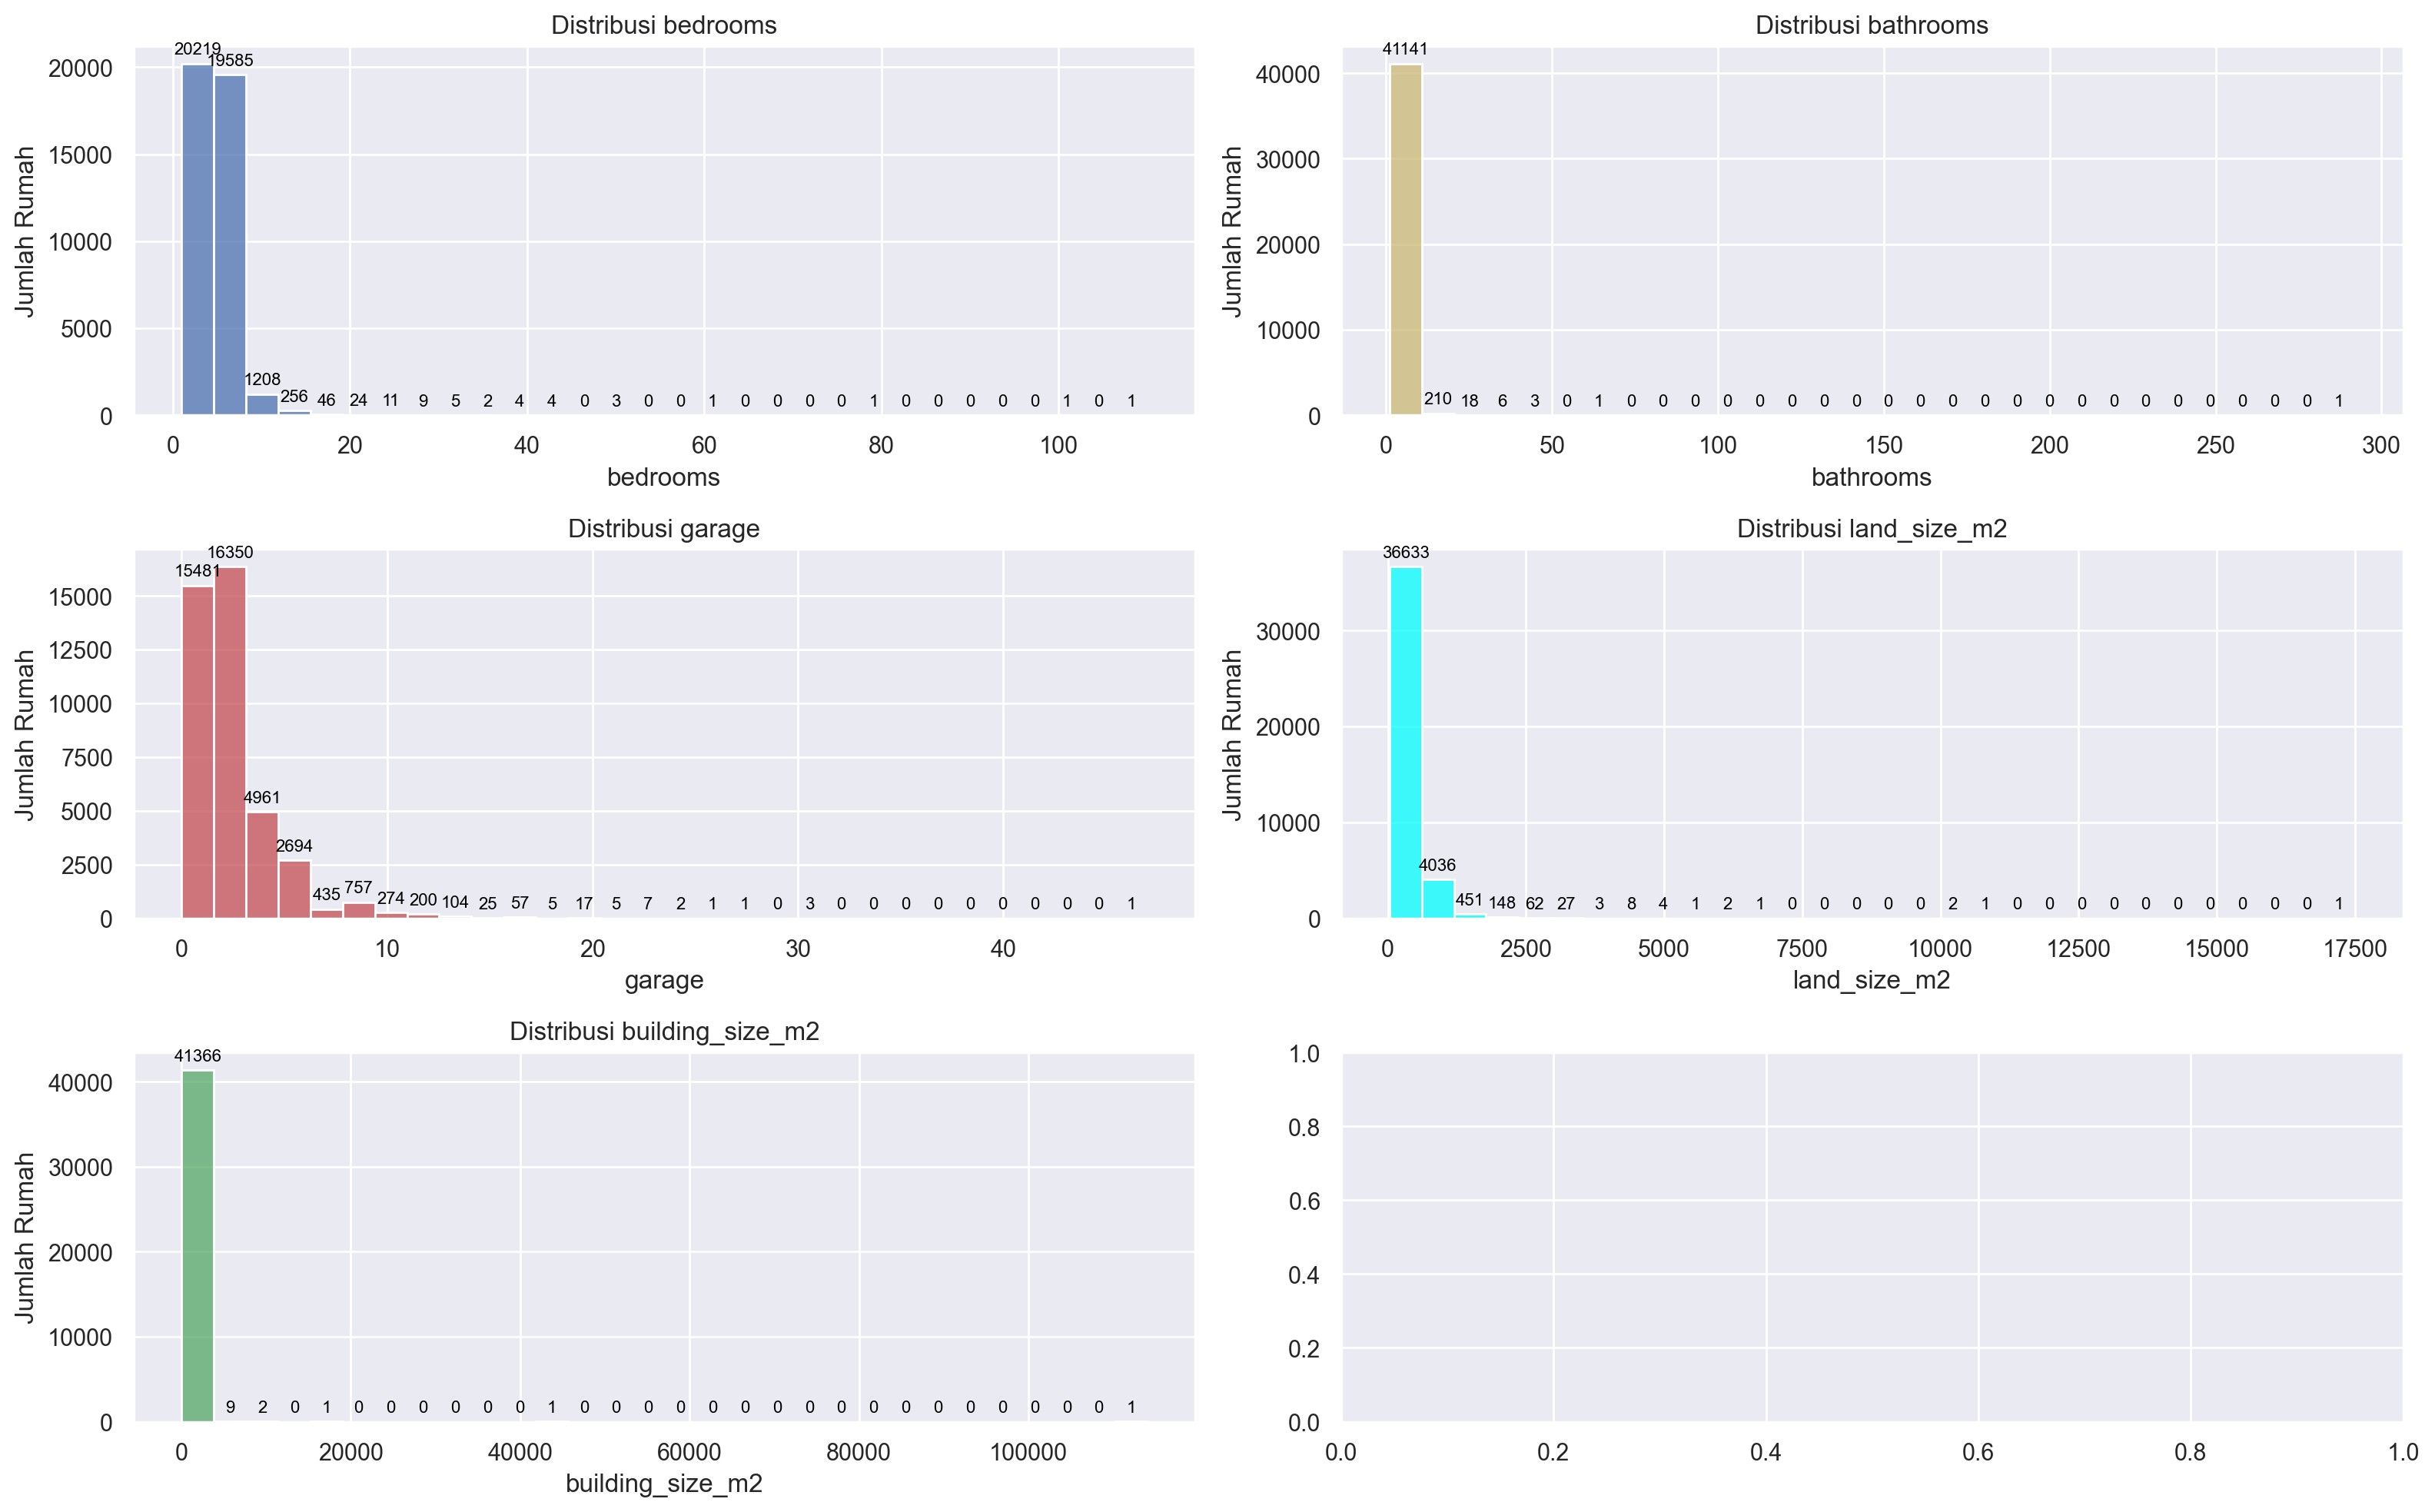

In [22]:
fig , axes = plt.subplots(3,2,figsize=(16,10),dpi=200)
axes = axes.flatten()

columns = ['bedrooms','bathrooms','garage','land_size_m2','building_size_m2']
collor = ['b','y','r','cyan','g']
col = zip(columns,collor)
n = 0

for k,v in col:
    sns.histplot(df[k],bins=30,color=v,ax=axes[n])
    axes[n].bar_label(axes[n].containers[0],fontsize=8,color='black',padding=3)
    axes[n].set_ylabel(f'Jumlah Rumah')
    axes[n].set_title(f'Distribusi {k}')
    n = n+1

fig.tight_layout()
plt.show()


In [23]:
df[df['garage'] > 10][['bedrooms', 'bathrooms', 'garage', 'land_size_m2', 'price_idr']]

,bedrooms,bathrooms,garage,land_size_m2,price_idr
29,9.0,6.0,22.0,2360.0,4.800000e+10
54,2.0,2.0,21.0,5555.0,5.500000e+10
86,18.0,20.0,12.0,584.0,4.000000e+10
87,3.0,4.0,14.0,1344.0,2.800000e+10
89,8.0,8.0,15.0,2382.0,8.900000e+10
...,...,...,...,...,...
49467,8.0,10.0,16.0,824.0,9.000000e+10
49520,8.0,10.0,16.0,824.0,9.000000e+10
49692,6.0,10.0,11.0,702.0,1.950000e+10
49784,7.0,6.0,18.0,850.0,8.000000e+10


In [24]:
df = df[(df['bedrooms'] <= 30) & (df['bathrooms'] <= 30) & (df['garage'] <= 30)]

## Memfilter atau memberi batas dan juga transformisasi pada kolom yang dibutuhkan untuk membuat distribusi menjadi normal

In [25]:
df['land_size_m2'] = np.log1p(df['land_size_m2'])
df['building_size_m2'] = np.log1p(df['building_size_m2'])
df['price_idr'] = np.log1p(df['price_idr'])

## Disribusi atau sebaran setiap kolom setelah melakukan normalisasi dengan cara clip dan log


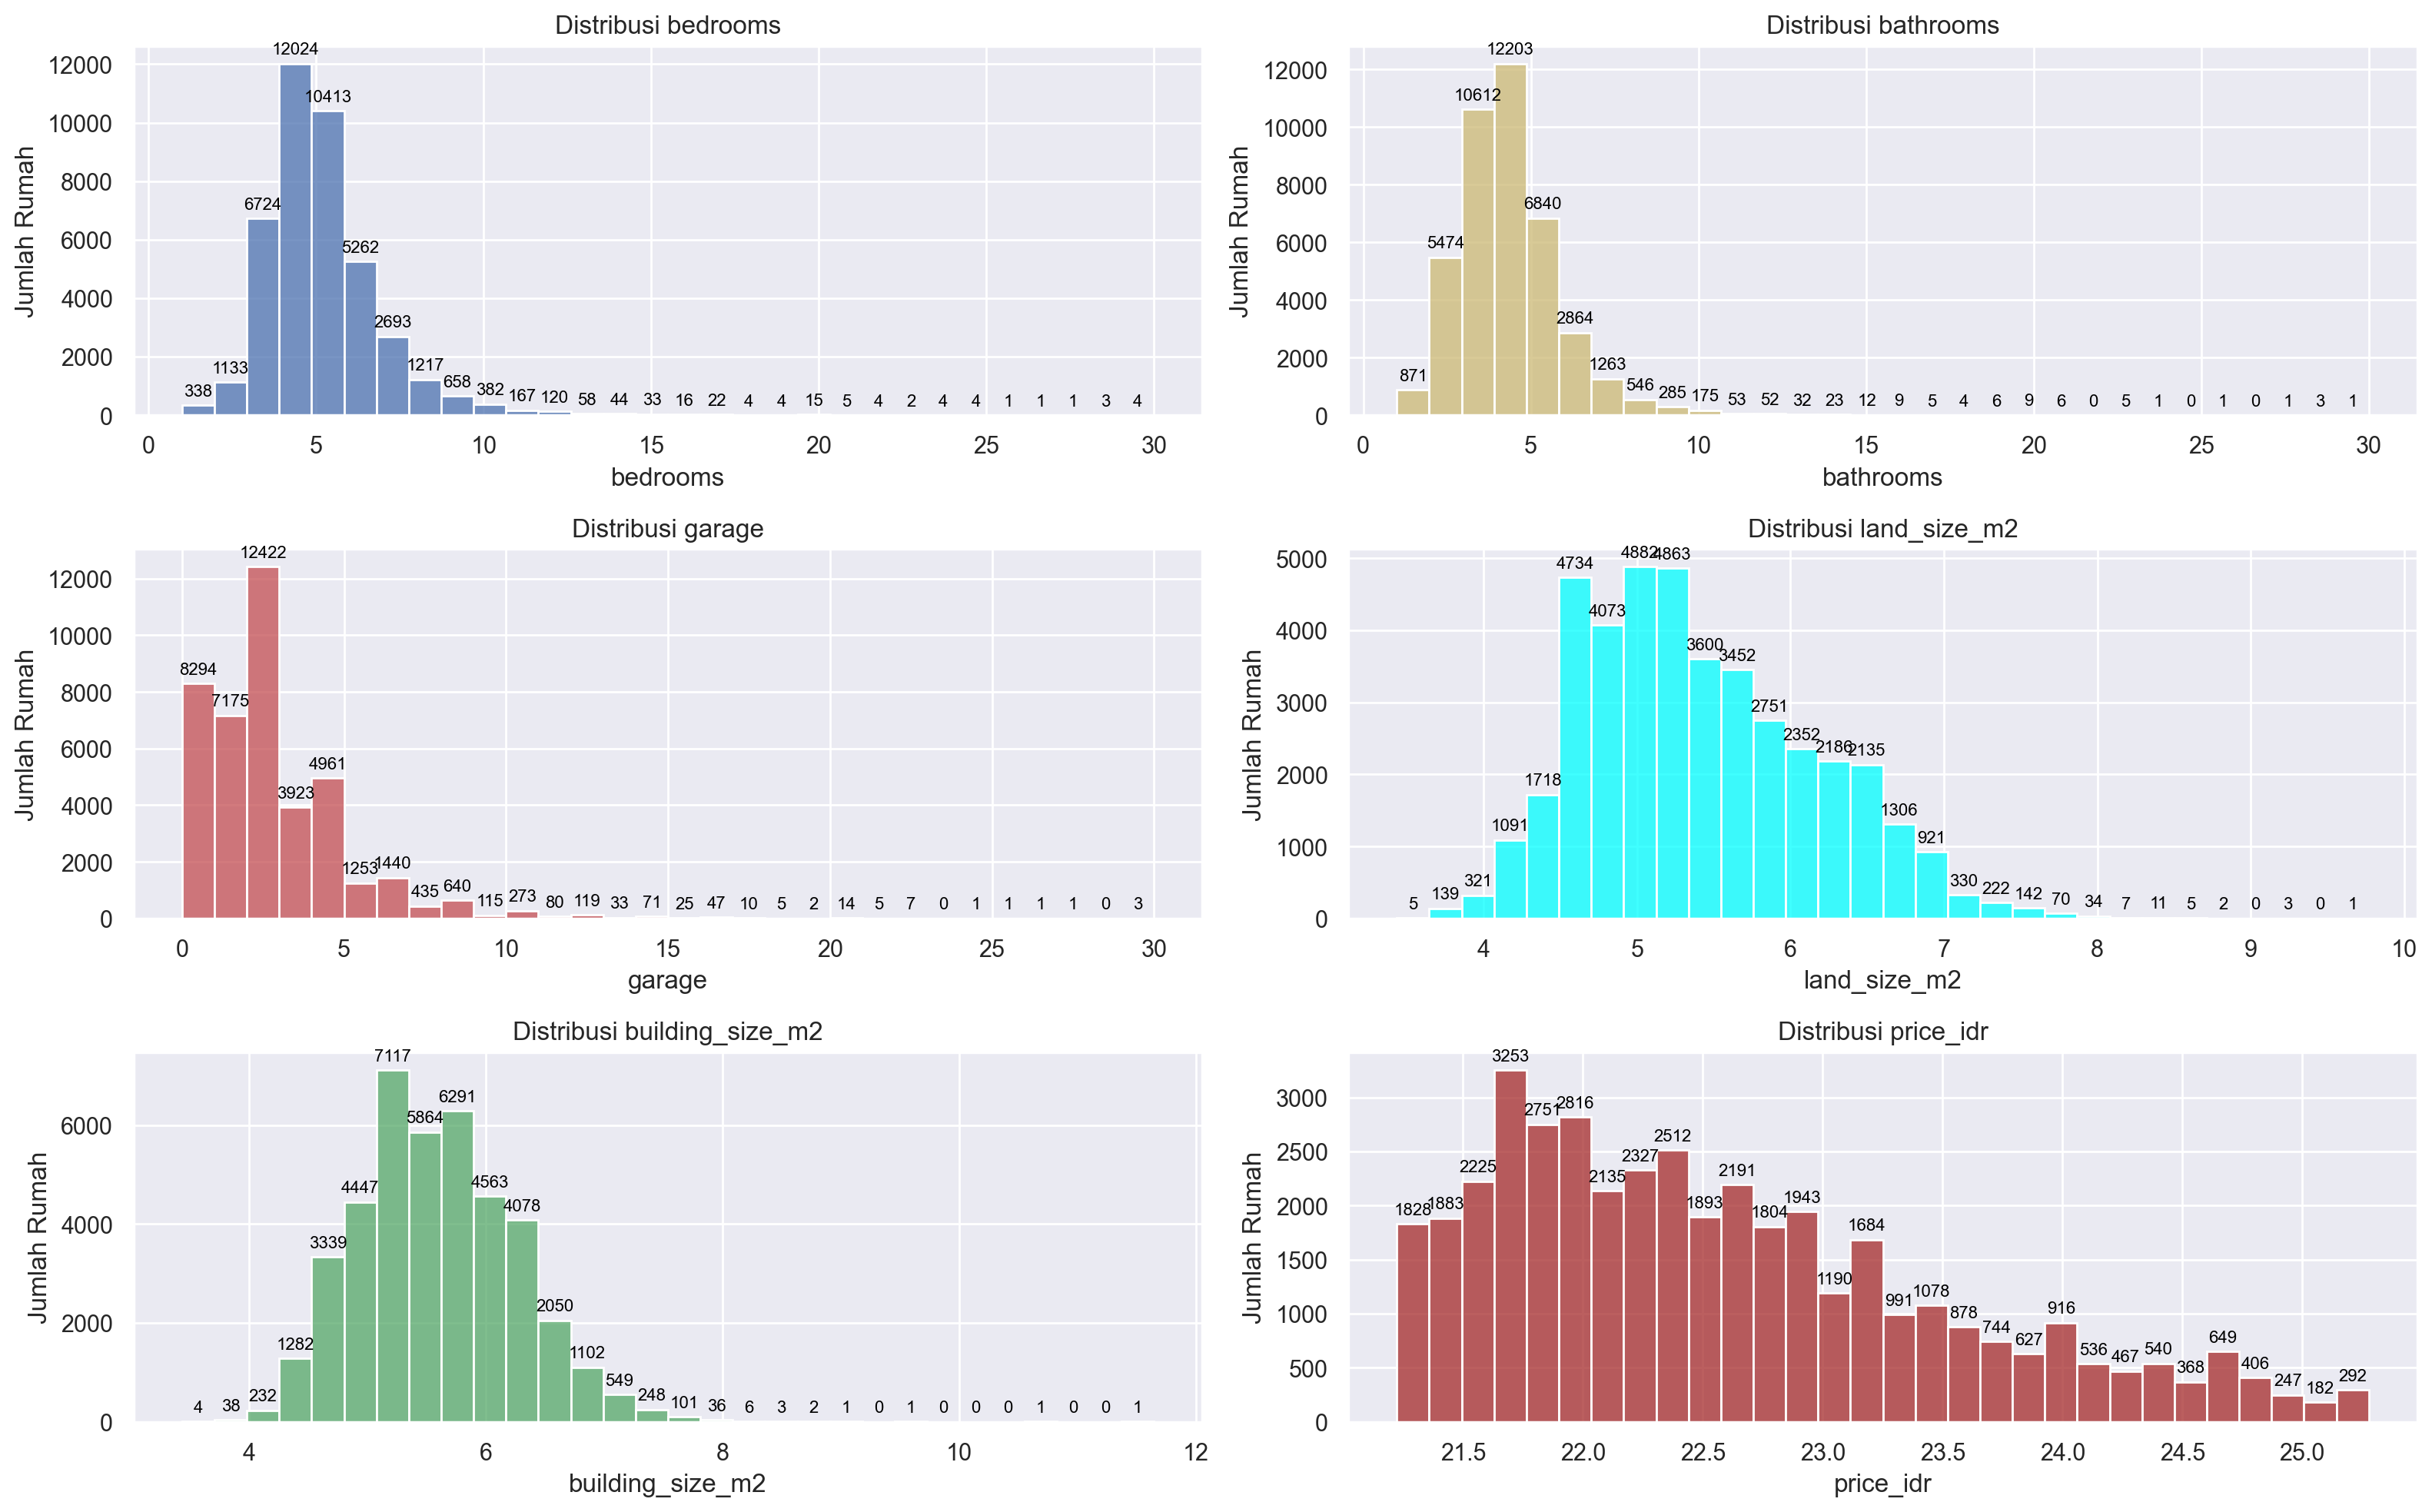

In [26]:
fig , axes = plt.subplots(3,2,figsize=(16,10),dpi=200)
axes = axes.flatten()

columns = ['bedrooms','bathrooms','garage','land_size_m2','building_size_m2','price_idr']
collor = ['b','y','r','cyan','g','brown']
col = zip(columns,collor)
n = 0

for k,v in col:
    sns.histplot(df[k],bins=30,color=v,ax=axes[n])
    axes[n].bar_label(axes[n].containers[0],fontsize=8,color='black',padding=3)
    axes[n].set_ylabel(f'Jumlah Rumah')
    axes[n].set_title(f'Distribusi {k}')
    n = n+1

fig.tight_layout()
plt.show()

In [27]:
df.describe()

,price_idr,bedrooms,bathrooms,garage,land_size_m2,building_size_m2,cluster,pool,mrt,tol,mall
count,41356.000000,41356.000000,41356.000000,41356.000000,41356.000000,41356.000000,41356.000000,41356.000000,41356.000000,41356.000000,41356.000000
mean,22.568833,4.830762,3.978407,2.329867,5.404243,5.593452,0.061877,0.027372,0.010035,0.024567,0.013323
std,0.938979,1.870053,1.693114,2.279078,0.758678,0.654573,0.240936,0.163167,0.099671,0.154804,0.114657
min,21.224041,1.000000,1.000000,0.000000,3.433987,3.433987,0.000000,0.000000,0.000000,0.000000,0.000000
25%,21.821878,4.000000,3.000000,1.000000,4.795791,5.129899,0.000000,0.000000,0.000000,0.000000,0.000000
50%,22.390973,5.000000,4.000000,2.000000,5.303305,5.525453,0.000000,0.000000,0.000000,0.000000,0.000000
75%,23.121161,6.000000,5.000000,3.000000,5.916202,5.993961,0.000000,0.000000,0.000000,0.000000,0.000000
max,25.277143,30.000000,30.000000,30.000000,9.770013,11.644226,1.000000,1.000000,1.000000,1.000000,1.000000


In [28]:
df[df['bathrooms'] > 50]

,title,price_idr,city,district,bedrooms,bathrooms,garage,land_size_m2,building_size_m2,scraped_at,cluster,pool,mrt,tol,mall


## **Melakukan Encoding Menggunakan OHE(One Hot Encoding)**


In [29]:
df = pd.get_dummies(df, columns=['city'], dtype=int)

## Menghapus kolom yang tidak butuhkan untuk tahap training model


In [30]:
df = df.drop(columns=['scraped_at','title'])

## Mapping district

In [31]:
with open("../data/district_mapping.json","r") as file:
    mapping = json.load(file)
print(mapping)

{'alfa indah': 'cengkareng', 'ampera': 'pasar minggu', 'ancol': 'pademangan', 'angke': 'tambora', 'antasari': 'cilandak', 'arjuna utara': 'grogol petamburan', 'bambu apus': 'cipayung', 'bandengan': 'penjaringan', 'bangka': 'mampang prapatan', 'batu ceper': 'gambir', 'batutulis': 'gambir', 'bedungan jatiluhur': 'tanah abang', 'bendungan hilir': 'tanah abang', 'bintaro': 'pesanggrahan', 'blok m': 'kebayoran baru', 'bojong indah': 'kembangan', 'buaran': 'duren sawit', 'bukit duri': 'tebet', 'bungur': 'senen', 'cakung': 'cakung', 'casablanca': 'tebet', 'cawang': 'kramat jati', 'cempaka mas': 'kemayoran', 'cempaka putih': 'cempaka putih', 'cengkareng': 'cengkareng', 'cengkareng barat': 'cengkareng', 'cibubur': 'ciracas', 'cideng': 'gambir', 'ciganjur': 'jagakarsa', 'cijantung': 'pasar rebo', 'cikini': 'menteng', 'cikoko': 'pancoran', 'cilandak': 'cilandak', 'cilangkap': 'cipayung', 'cililitan': 'kramat jati', 'cilincing': 'cilincing', 'cinere': 'cilandak', 'cipayung': 'cipayung', 'cipedak':

## Membuat logic ketika district gaada maka akan masuk ke log agar bisa segera di perbarui mappingnya


In [32]:
df['district'] = df['district'].str.lower()
unknown = set(df[~df['district'].isin(mapping.keys())]['district'].unique())
if len(unknown) > 0:
    print(f"{len(unknown)} district tidak ada di mapping:")
    for d in sorted(unknown):
           print(f" - '{d}'")

log_unknown = Path("../log/unknown_district.log")
logged = set()
if log_unknown.exists():
      with open(log_unknown,"r") as file:
            logged = {i.strip() for i in file}

new_unknown = unknown - logged
if new_unknown:
      with open(log_unknown,"a") as file:
        for d in sorted(new_unknown):
            file.write(f"{d}\n")

df['district'] = df['district'].map(mapping)



In [33]:
df.info()

<class 'pandas.DataFrame'>
Index: 41356 entries, 0 to 49951
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   price_idr             41356 non-null  float64
 1   district              41356 non-null  str    
 2   bedrooms              41356 non-null  float64
 3   bathrooms             41356 non-null  float64
 4   garage                41356 non-null  float64
 5   land_size_m2          41356 non-null  float64
 6   building_size_m2      41356 non-null  float64
 7   cluster               41356 non-null  int64  
 8   pool                  41356 non-null  int64  
 9   mrt                   41356 non-null  int64  
 10  tol                   41356 non-null  int64  
 11  mall                  41356 non-null  int64  
 12  city_Jakarta Barat    41356 non-null  int64  
 13  city_Jakarta Pusat    41356 non-null  int64  
 14  city_Jakarta Selatan  41356 non-null  int64  
 15  city_Jakarta Timur    41356 non-nul

In [34]:
df.head()

,price_idr,district,bedrooms,bathrooms,garage,land_size_m2,building_size_m2,cluster,pool,mrt,tol,mall,city_Jakarta Barat,city_Jakarta Pusat,city_Jakarta Selatan,city_Jakarta Timur,city_Jakarta Utara
0,21.311053,pesanggrahan,3.0,2.0,2.0,4.795791,4.394449,0,0,0,0,0,0,0,1,0,0
1,22.654787,tebet,4.0,4.0,4.0,4.343805,5.929589,0,0,0,0,0,0,0,1,0,0
2,23.025851,kembangan,4.0,4.0,2.0,5.420535,6.216606,0,0,0,0,0,1,0,0,0,0
5,21.787977,kelapa gading,4.0,4.0,0.0,4.634729,4.634729,0,0,0,0,0,0,0,0,0,1
6,21.947041,duren sawit,3.0,2.0,4.0,4.663439,4.691348,1,0,0,0,0,0,0,0,1,0


In [35]:
df.to_csv("../data/processed/jakarta_properties_processed2.csv",index=False)